In [1]:
import os
import tqdm
import parselmouth
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_dir = "./hw1_data"
timedata_df = pd.read_csv(
    os.path.join(data_dir, "timedata.dat"),
    skiprows=5,
    sep=r"\s+",
)
print(timedata_df.head())

    File  Start    End  Center1  Center2
0  m01ae  177.3  500.4    304.0    297.0
1  m02ae  132.0  382.0    198.0    240.0
2  m03ae  118.0  462.0    162.0    181.0
3  m04ae   96.0  408.0    130.0    169.0
4  m06ae   71.0  325.0    113.0    134.0


In [3]:
out_dir = './output'
plot_out_dir = os.path.join(out_dir, "problem1")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plot_out_dir, exist_ok=True)

## Formant extraction

### Extracting Pitch and Formants

In [4]:
def get_max_formant(file_id):
    group = file_id[0].lower()
    if group == "m":
        return 5000, "men"
    elif group == "w":
        return 5500, "women"
    elif group in ["b", "g"]:
        return 8000, "children"
    else:
        raise ValueError(f"Unknown speaker group: {group}")

def get_steady_state_window(center, steady_state_proportion, start, end):
    window_length = steady_state_proportion * (end - start)
    steady_start = max(center - window_length / 2, start)
    steady_end = min(center + window_length / 2, end)
    return steady_start, steady_end

def sample_from_steady_state(pitch, formants, steady_start, steady_end, time_step=0.01):
    sample_times = np.arange(
        steady_start,
        steady_end + 1e-9,
        time_step
    )

    F_values = []
    F0 = np.nanmean([pitch.get_value_at_time(t) for t in sample_times])
    F_values.append(F0)
    
    for i in range(1, 5):
        values = [formants.get_value_at_time(i, t) for t in sample_times]
        F_values.append(np.nanmean(values))

    return F_values

steady_state_proportion = 0.33
extracted_formants_path = os.path.join(out_dir, "extracted_formants.csv")
if os.path.exists(extracted_formants_path):
    extracted_formants_df = pd.read_csv(extracted_formants_path)
else:
    extracted_formants = []

    for index, row in tqdm.tqdm(timedata_df.iterrows(), total=timedata_df.shape[0]):
        vow_token = row['File'][-2:]
        audio_path = os.path.join(data_dir, row["File"] + ".wav")
        assert os.path.exists(audio_path), f"Audio file not found: {audio_path}"

        # Load sound file using Parselmouth
        sound = parselmouth.Sound(audio_path)

        max_formant, speaker_group = get_max_formant(row["File"])

        start = row["Start"] / 1000
        end = row["End"] / 1000
        center = ((row["Center1"] + row["Center2"]) / 2) / 1000
        steady_start, steady_end = get_steady_state_window(center, steady_state_proportion, start, end)

        # F0
        pitch = sound.to_pitch(time_step=0.01)

        # Extract F1, F2, F3, F4 using the Burg method
        formants = sound.to_formant_burg(
            time_step=0.01,
            max_number_of_formants=5,
            maximum_formant=max_formant,
            window_length=0.025
        )

        F0, F1, F2, F3, F4 = sample_from_steady_state(pitch, formants, steady_start, steady_end)

        extracted_formants.append({
            **row,
            "group": speaker_group,
            "steady_start": round(steady_start * 1000, 1),
            "steady_end": round(steady_end * 1000, 1),
            "f0": F0.item(),
            "f1": F1.item(),
            "f2": F2.item(),
            "f3": F3.item(),
            "f4": F4.item()
        })

    extracted_formants_df = pd.DataFrame(extracted_formants)
    extracted_formants_df.to_csv(extracted_formants_path, index=False)


### Visualize

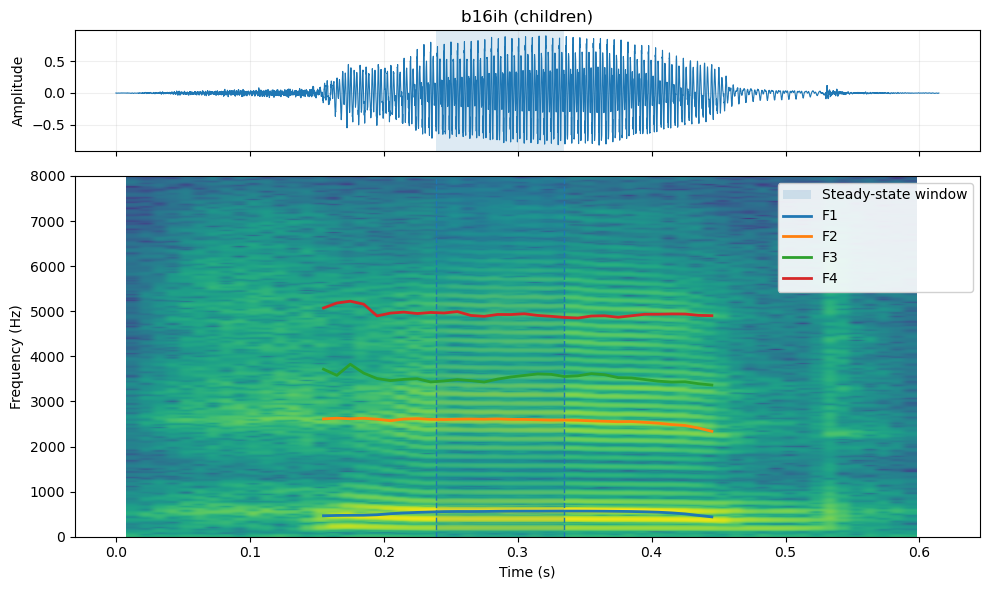

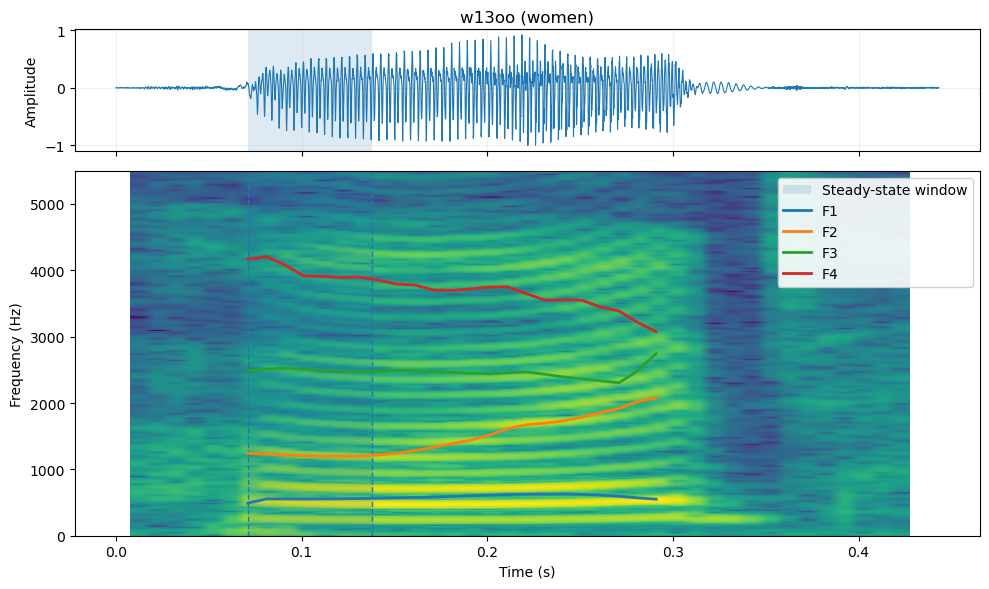

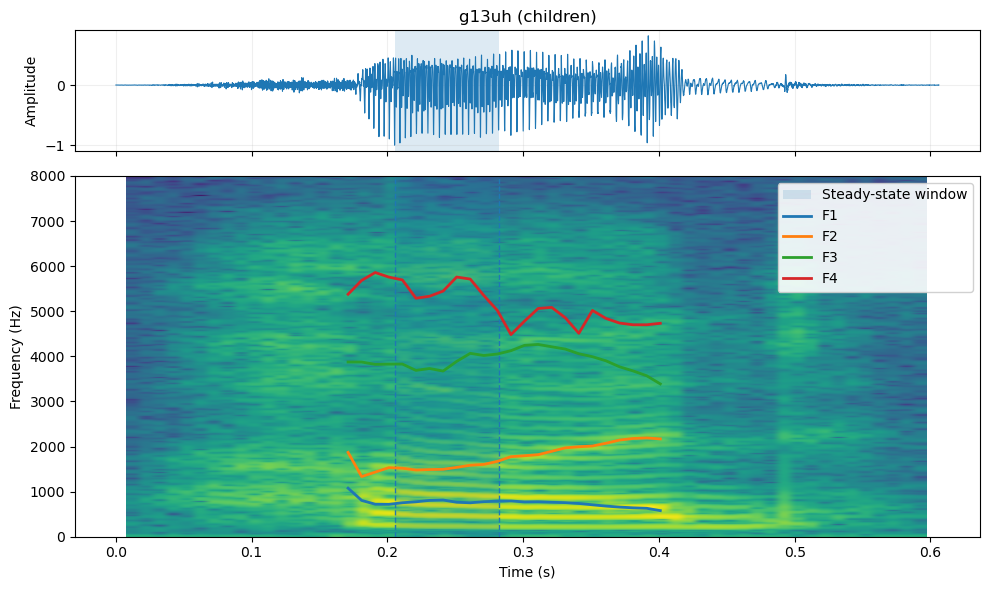

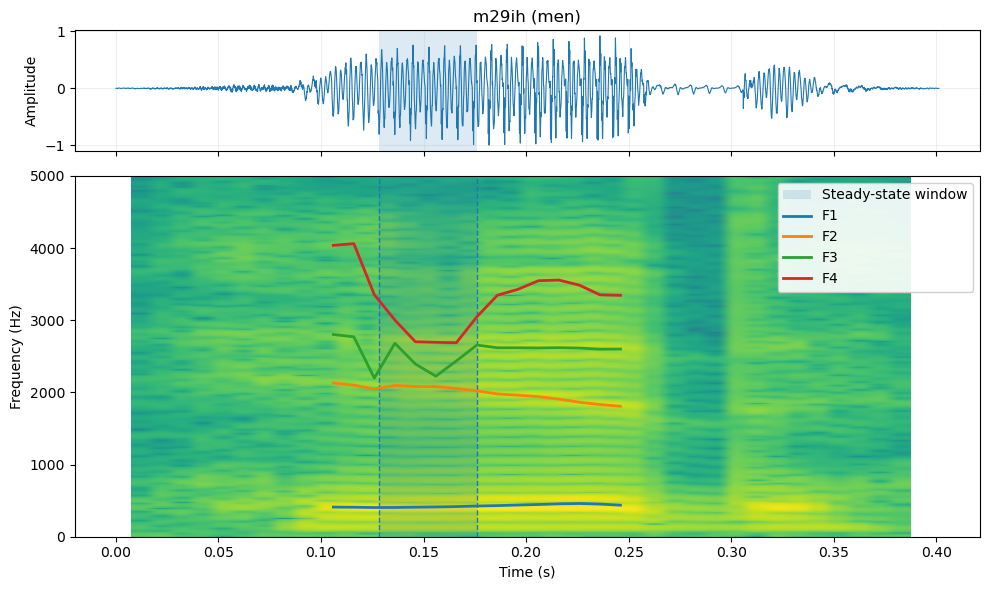

In [5]:
sample_df = extracted_formants_df.sample(n=4, random_state=1)
for _, row in sample_df.iterrows():
    audio_path = os.path.join(data_dir, row["File"] + ".wav")
    assert os.path.exists(audio_path), f"Audio file not found: {audio_path}"

    # Load sound file using Parselmouth
    sound = parselmouth.Sound(audio_path)

    max_formant, speaker_group = get_max_formant(row["File"])

    start = row["Start"] / 1000
    end = row["End"] / 1000
    steady_start, steady_end = row["steady_start"]/1000, row["steady_end"]/1000

    # F0
    pitch = sound.to_pitch(time_step=0.01)

    # Extract F1, F2, F3, F4 using the Burg method
    formants = sound.to_formant_burg(
        time_step=0.01,
        max_number_of_formants=5,
        maximum_formant=max_formant,
        window_length=0.025
    )

    sampling_points = np.arange(start, end + 1e-9, 0.01)
    formant_tracks = {
        'f0': np.array([pitch.get_value_at_time(t) for t in sampling_points]),
        'f1': np.array([formants.get_value_at_time(1, t) for t in sampling_points]),
        'f2': np.array([formants.get_value_at_time(2, t) for t in sampling_points]),
        'f3': np.array([formants.get_value_at_time(3, t) for t in sampling_points]),
        'f4': np.array([formants.get_value_at_time(4, t) for t in sampling_points])
    }

    fig, (ax_wave, ax_spec) = plt.subplots(
        2, 1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 3]}
    )

    fs = sound.sampling_frequency
    wave = sound.values[0]
    times = np.arange(len(wave)) / fs

    # Waveform
    ax_wave.plot(times, wave, linewidth=0.8)
    ax_wave.axvspan(
        steady_start,
        steady_end,
        alpha=0.15,
        label="Steady-state window"
    )

    ax_wave.set_ylabel("Amplitude")
    ax_wave.set_title(row["File"] + f" ({speaker_group})")
    ax_wave.grid(alpha=0.2)


    # Spectrogram
    nfft = int(0.025 * fs)
    hop = int(0.010 * fs)
    noverlap = nfft - hop
    ax_spec.specgram(
        wave,
        NFFT=nfft,
        Fs=fs,
        noverlap=noverlap,
        pad_to=1024
    )

    ax_spec.axvspan(
        steady_start,
        steady_end,
        alpha=0.15,
        label="Steady-state window"
    )
    ax_spec.axvline(
        steady_start,
        linestyle="--",
        linewidth=1
    )
    ax_spec.axvline(
        steady_end,
        linestyle="--",
        linewidth=1
    )

    # Formant tracks
    for f in ["f1", "f2", "f3", "f4"]:
        ax_spec.plot(
            sampling_points,
            formant_tracks[f],
            linewidth=2,
            label=f.upper()
        )

    ax_spec.set_xlabel("Time (s)")
    ax_spec.set_ylabel("Frequency (Hz)")

    max_formant, speaker_group = get_max_formant(row["File"])
    ax_spec.set_ylim(0, max_formant)

    ax_spec.legend(
        loc="upper right",
        framealpha=0.9
    )

    plt.tight_layout()
    plt.savefig(os.path.join(plot_out_dir, row["File"] + "_steady_state.pdf"))
    plt.show()

### Validate

In [6]:
vowdata_df = pd.read_csv(
    os.path.join(data_dir, "vowdata.dat"),
    skiprows=30,
    sep=r"\s+",
    header=None,
    names=[
        "filename",
        "duration",
        "f0",
        "f1",
        "f2",
        "f3",
        "f4",
        "f1_at_20",
        "f2_at_20",
        "f3_at_20",
        "f1_at_50",
        "f2_at_50",
        "f3_at_50",
        "f1_at_80",
        "f2_at_80",
        "f3_at_80",
    ]
)

merged_df = pd.merge(extracted_formants_df, vowdata_df, left_on="File", right_on="filename")
merged_df = merged_df[['filename', 'f1_x', 'f2_x', 'f1_y', 'f2_y']]
group_map = {
    'm': 'men',
    'w': 'women',
    'b': 'children',
    'g': 'children'
}
merged_df['group'] = merged_df['filename'].apply(lambda x: group_map.get(x[0], 'unknown'))
# discard rows with 0
merged_df = merged_df[(merged_df['f1_x'] != 0) & (merged_df['f2_x'] != 0) & (merged_df['f1_y'] != 0) & (merged_df['f2_y'] != 0)]

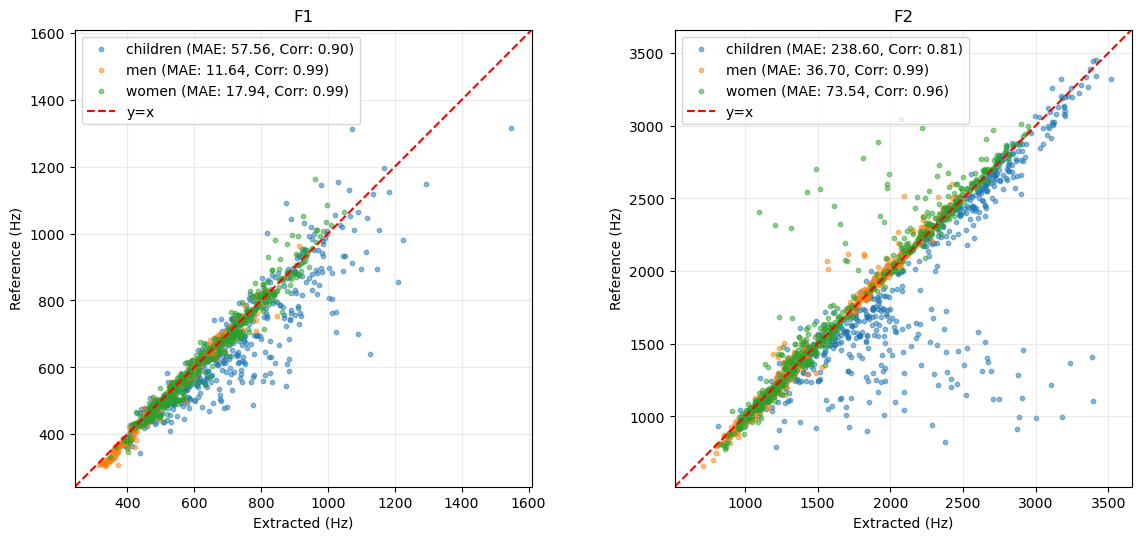

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))

formants = [
    ("f1_x", "f1_y", "F1"),
    ("f2_x", "f2_y", "F2"),
]

for a, (x_col, y_col, title) in zip(ax, formants):

    # Scatter by speaker group
    for group, group_df in merged_df.groupby("group"):
        mae = (group_df[x_col] - group_df[y_col]).abs().mean()
        corr = group_df[[x_col, y_col]].corr().iloc[0, 1]
        a.scatter(
            group_df[x_col],
            group_df[y_col],
            label=group + f" (MAE: {mae:.2f}, Corr: {corr:.2f})",
            alpha=0.5,
            s=10
        )



    # Same numerical range for x and y
    min_val = min(
        merged_df[x_col].min(),
        merged_df[y_col].min()
    )
    max_val = max(
        merged_df[x_col].max(),
        merged_df[y_col].max()
    )
    padding = 0.05 * (max_val - min_val)
    limits = (min_val - padding, max_val + padding)
    a.set_xlim(limits)
    a.set_ylim(limits)

    # y = x reference line
    a.plot(
        limits,
        limits,
        "--",
        linewidth=1.5,
        label="y=x",
        c="r",
    )

    a.set_aspect("equal", adjustable="box")

    a.set_title(title)
    a.set_xlabel("Extracted (Hz)")
    a.set_ylabel("Reference (Hz)")

    a.grid(alpha=0.25)
    a.legend()

plt.tight_layout()
plt.savefig(os.path.join(plot_out_dir, "formant_comparison.pdf"))
plt.show()

## Group differences in vowel space

In [8]:
vowelspace_df = extracted_formants_df[['File', 'group', 'f1', 'f2']].copy()
vowelspace_df['vowel'] = vowelspace_df['File'].str[-2:]
print(vowelspace_df.head())


    File group          f1           f2 vowel
0  m01ae   men  660.128601  1972.395731    ae
1  m02ae   men  640.905347  1802.378084    ae
2  m03ae   men  609.936178  1780.819994    ae
3  m04ae   men  630.551106  1925.831368    ae
4  m06ae   men  654.601432  1846.140090    ae


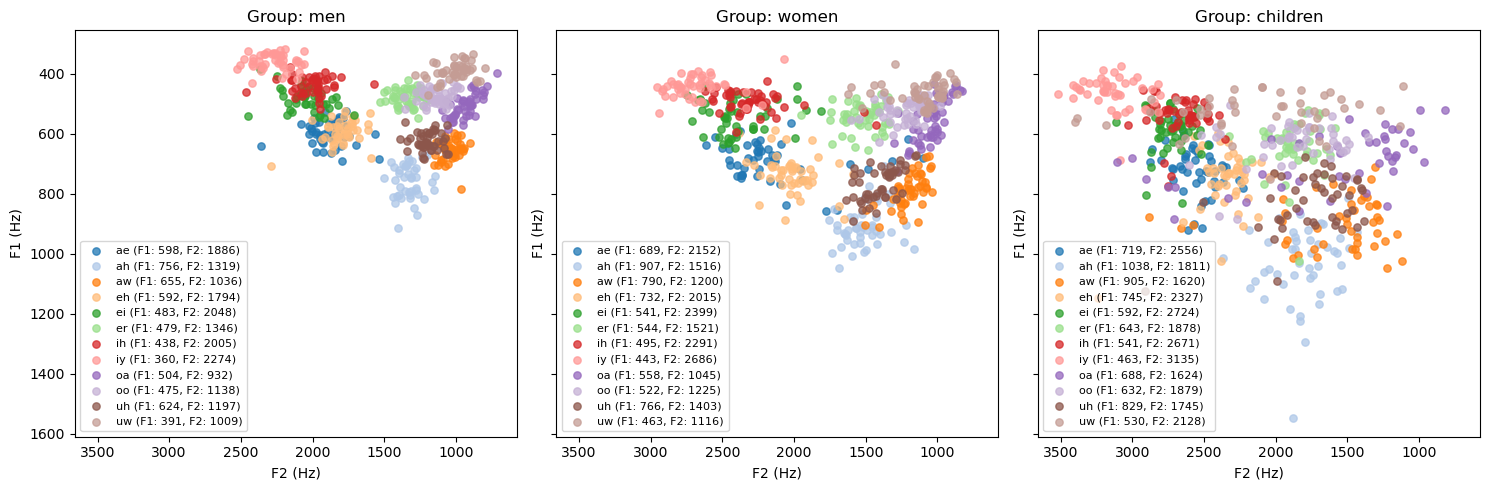

In [9]:
vowels = sorted(vowelspace_df["vowel"].unique())
cmap = plt.get_cmap("tab20")

vowel_colors = {
    vowel: cmap(i)
    for i, vowel in enumerate(vowels)
}

fig, ax = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

groups = vowelspace_df["group"].unique()

for i, group in enumerate(groups):
    subset = vowelspace_df[vowelspace_df["group"] == group]

    for vowel, vowel_subset in subset.groupby("vowel"):
        mean_f1 = vowel_subset["f1"].mean()
        mean_f2 = vowel_subset["f2"].mean()

        ax[i].scatter(
            vowel_subset["f2"],
            vowel_subset["f1"],
            color=vowel_colors[vowel],
            alpha=0.75,
            s=28,
            label=f"{vowel} (F1: {mean_f1:.0f}, F2: {mean_f2:.0f})"
        )

    ax[i].set_title(f"Group: {group}")
    ax[i].set_xlabel("F2 (Hz)")
    ax[i].set_ylabel("F1 (Hz)")

    ax[i].invert_xaxis()
    ax[i].invert_yaxis()

    ax[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(plot_out_dir, "vowel_space.pdf"), dpi=1000)
plt.show()

## Vocal-tract-length estimation

In [10]:
speaker_df = extracted_formants_df.copy()
speaker_df['speaker_id'] = speaker_df['File'].apply(lambda x: x[:3])

vtl_df = []
for speaker_id in speaker_df['speaker_id'].unique():
    subset = speaker_df[speaker_df['speaker_id'] == speaker_id]
    mean_F1 = subset['f1'].mean()
    mean_F2 = subset['f2'].mean()
    mean_F3 = subset['f3'].mean()
    mean_F4 = subset['f4'].mean()

    delta_F = ((mean_F2 - mean_F1) + (mean_F3 - mean_F2) + (mean_F4 - mean_F3))/3
    L = 35000 / (2 * delta_F)

    vtl_df.append({'speaker_id': speaker_id, 'vtl': L.item(), 'group': subset['group'].iloc[0]})
vtl_df = pd.DataFrame(vtl_df)

In [11]:
# Flag IQR outliers within each speaker group
vtl_df = vtl_df.copy()
vtl_df["outlier"] = False

for group in vtl_df["group"].unique():
    mask = vtl_df["group"] == group
    vals = vtl_df.loc[mask, "vtl"].dropna()

    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    vtl_df.loc[mask, "outlier"] = (
        (vtl_df.loc[mask, "vtl"] < lower) |
        (vtl_df.loc[mask, "vtl"] > upper)
    )

    print(
        f"{group}: "
        f"Mean: {vals.mean():.2f}, Std: {vals.std():.2f},"
        f" IQR bounds = [{lower:.2f}, {upper:.2f}] cm"
    )

men: Mean: 18.11, Std: 1.26, IQR bounds = [15.42, 20.79] cm
women: Mean: 15.54, Std: 0.81, IQR bounds = [13.42, 17.60] cm
children: Mean: 12.06, Std: 0.58, IQR bounds = [10.75, 13.36] cm


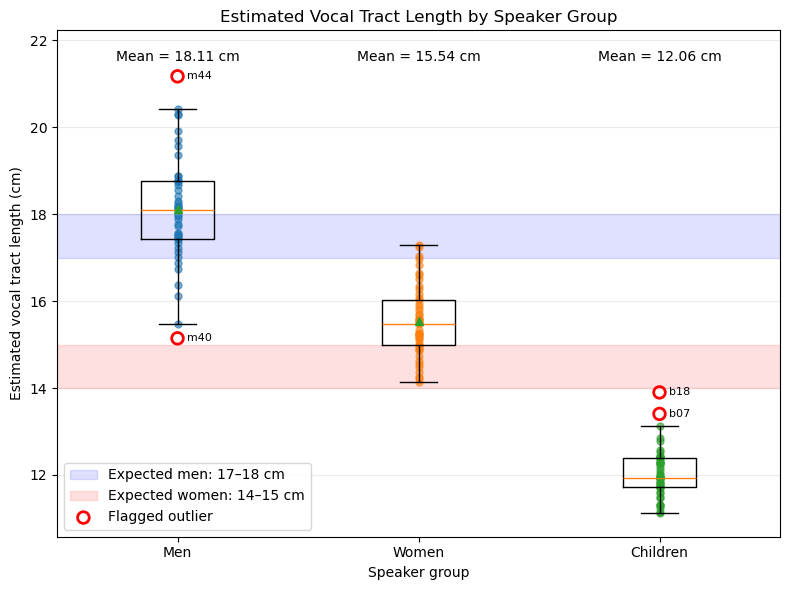

In [12]:
groups = ["men", "women", "children"]
data = [
    vtl_df.loc[vtl_df["group"] == group, "vtl"].dropna()
    for group in groups
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    data,
    tick_labels=["Men", "Women", "Children"],
    showmeans=True,
    showfliers=False
)

# Expected adult ranges
ax.axhspan(
    17, 18,
    alpha=0.12,
    label="Expected men: 17–18 cm",
    color="b"
)

ax.axhspan(
    14, 15,
    alpha=0.12,
    label="Expected women: 14–15 cm",
    color="r"
)

y_min = vtl_df["vtl"].min()
y_max = vtl_df["vtl"].max()
ax.set_ylim(y_min * 0.95, y_max * 1.05)

for i, group in enumerate(groups, start=1):

    group_df = vtl_df[
        (vtl_df["group"] == group) &
        (vtl_df["vtl"].notna())
    ]

    normal = group_df[~group_df["outlier"]]
    outliers = group_df[group_df["outlier"]]

    # Normal speakers
    ax.scatter(
        np.full(len(normal), i),
        normal["vtl"],
        alpha=0.6,
        s=25
    )

    # Outliers
    ax.scatter(
        np.full(len(outliers), i),
        outliers["vtl"],
        s=70,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        zorder=5,
        label="Flagged outlier" if i == 1 else None
    )
    for _, row in outliers.iterrows():
        ax.annotate(
            row["speaker_id"],
            (i, row["vtl"]),
            xytext=(7, 0),
            textcoords="offset points",
            fontsize=8,
            va="center"
        )

    mean_vtl = group_df["vtl"].mean()

    ax.text(
        i,
        ax.get_ylim()[1] * 0.98,
        f"Mean = {mean_vtl:.2f} cm",
        ha="center",
        va="top"
    )

ax.set_ylabel("Estimated vocal tract length (cm)")
ax.set_xlabel("Speaker group")
ax.set_title("Estimated Vocal Tract Length by Speaker Group")

ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(plot_out_dir, "vtl_by_group.pdf"))
plt.show()

## Formant normalization based on VTL

In [13]:
mean_vtl = vtl_df["vtl"].mean()
normalized_vtl_df = vtl_df.copy()
normalized_vtl_df["normalized_ratio"] = normalized_vtl_df["vtl"] / mean_vtl
print(normalized_vtl_df)

    speaker_id        vtl     group  outlier  normalized_ratio
0          m01  20.415502       men    False          1.341480
1          m02  18.661343       men    False          1.226216
2          m03  18.785490       men    False          1.234374
3          m04  17.025287       men    False          1.118713
4          m06  17.963379       men    False          1.180354
..         ...        ...       ...      ...               ...
134        g17  12.248807  children    False          0.804856
135        g18  11.842377  children    False          0.778150
136        g19  12.118394  children    False          0.796286
137        g20  12.409438  children    False          0.815411
138        g21  11.928416  children    False          0.783803

[139 rows x 5 columns]


In [14]:
normalized_vowelspace_df = []
for _, row in vowelspace_df.iterrows():
    speaker_id = row['File'][:3]
    normalized_ratio = normalized_vtl_df.loc[normalized_vtl_df["speaker_id"] == speaker_id, "normalized_ratio"].values[0]
    normalized_vowelspace_df.append({
        'File': row['File'],
        'group': row['group'],
        'f1': row['f1'] * normalized_ratio,
        'f2': row['f2'] * normalized_ratio,
        'vowel': row['vowel']
    })
normalized_vowelspace_df = pd.DataFrame(normalized_vowelspace_df)
normalized_vowelspace_df.to_csv(os.path.join(out_dir,"normalized_vowelspace.csv"), index=False)

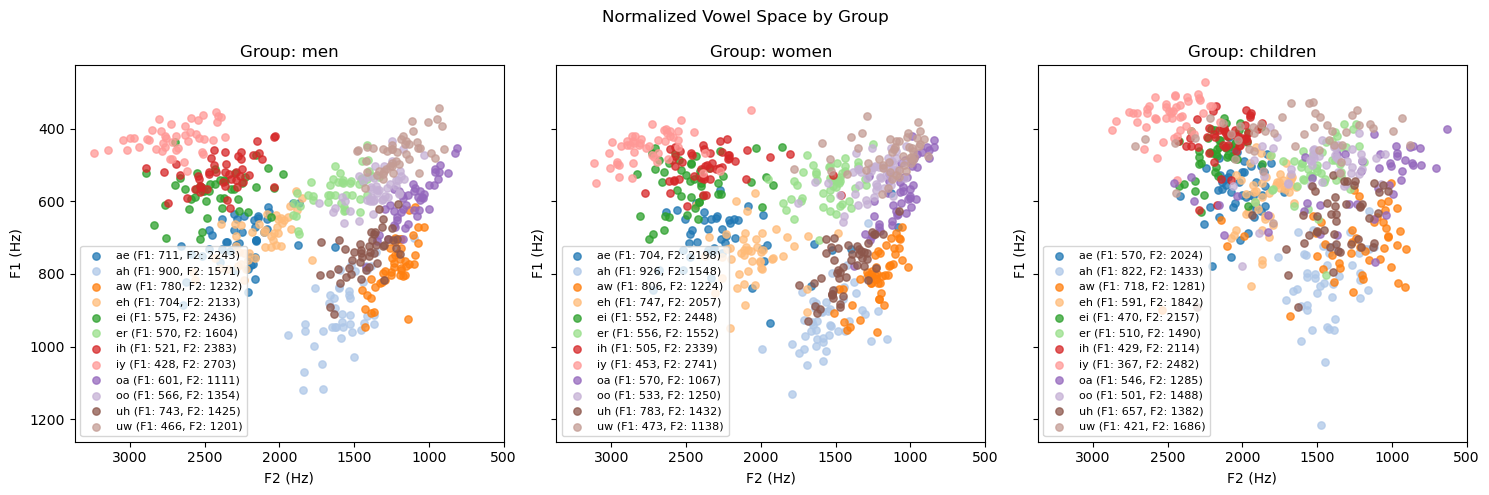

In [15]:
vowels = sorted(normalized_vowelspace_df["vowel"].unique())
cmap = plt.get_cmap("tab20")

vowel_colors = {
    vowel: cmap(i)
    for i, vowel in enumerate(vowels)
}

fig, ax = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

groups = normalized_vowelspace_df["group"].unique()

for i, group in enumerate(groups):
    subset = normalized_vowelspace_df[normalized_vowelspace_df["group"] == group]

    for vowel, vowel_subset in subset.groupby("vowel"):
        mean_f1 = vowel_subset["f1"].mean()
        mean_f2 = vowel_subset["f2"].mean()

        ax[i].scatter(
            vowel_subset["f2"],
            vowel_subset["f1"],
            color=vowel_colors[vowel],
            alpha=0.75,
            s=28,
            label=f"{vowel} (F1: {mean_f1:.0f}, F2: {mean_f2:.0f})"
        )

    ax[i].set_title(f"Group: {group}")
    ax[i].set_xlabel("F2 (Hz)")
    ax[i].set_ylabel("F1 (Hz)")

    ax[i].invert_xaxis()
    ax[i].invert_yaxis()

    ax[i].legend(fontsize=8)

fig.suptitle("Normalized Vowel Space by Group")
plt.tight_layout()
plt.savefig(os.path.join(plot_out_dir, "normalized_vowel_space.pdf"))
plt.show()

### Pairwise distance

In [16]:
vowelgroup_centroids = []
for group in vowelspace_df['group'].unique():
    for vowel in vowelspace_df["vowel"].unique():
        subset = vowelspace_df[
            (vowelspace_df["group"] == group) &
            (vowelspace_df["vowel"] == vowel)
        ]
        mean_f1 = subset["f1"].mean()
        mean_f2 = subset["f2"].mean()
        vowelgroup_centroids.append({
            'group': group,
            'vowel': vowel,
            'mean_f1': mean_f1,
            'mean_f2': mean_f2
        })
vowelgroup_centroids = pd.DataFrame(vowelgroup_centroids)

In [17]:
normalized_vowelgroup_centroids = []
for group in normalized_vowelspace_df['group'].unique():
    for vowel in normalized_vowelspace_df["vowel"].unique():
        subset = normalized_vowelspace_df[
            (normalized_vowelspace_df["group"] == group) &
            (normalized_vowelspace_df["vowel"] == vowel)
        ]
        mean_f1 = subset["f1"].mean()
        mean_f2 = subset["f2"].mean()
        normalized_vowelgroup_centroids.append({
            'group': group,
            'vowel': vowel,
            'mean_f1': mean_f1,
            'mean_f2': mean_f2
        })
normalized_vowelgroup_centroids = pd.DataFrame(normalized_vowelgroup_centroids)

In [18]:
def get_pairwise_distances(centroids_1, centroids_2):
    distances = []
    for i, row1 in centroids_1.iterrows():
        for j, row2 in centroids_2.iterrows():
            if row1['vowel'] == row2['vowel']:
                dist = ((row1['mean_f1'] - row2['mean_f1'])**2 + (row1['mean_f2'] - row2['mean_f2'])**2)**0.5
                distances.append({
                    'vowel': row1['vowel'],
                    'group_1': row1['group'],
                    'group_2': row2['group'],
                    'distance': dist
                })
    return pd.DataFrame(distances)

In [19]:
pairwise_distances = {
    'men_women': get_pairwise_distances(vowelgroup_centroids[vowelgroup_centroids['group'] == 'men'],
                                         vowelgroup_centroids[vowelgroup_centroids['group'] == 'women']),
    'men_women_normalized': get_pairwise_distances(normalized_vowelgroup_centroids[normalized_vowelgroup_centroids['group'] == 'men'],
                                                              normalized_vowelgroup_centroids[normalized_vowelgroup_centroids['group'] == 'women']),
    'men_children': get_pairwise_distances(vowelgroup_centroids[vowelgroup_centroids['group'] == 'men'],
                                           vowelgroup_centroids[vowelgroup_centroids['group'] == 'children']),
    'men_children_normalized': get_pairwise_distances(normalized_vowelgroup_centroids[normalized_vowelgroup_centroids['group'] == 'men'],
                                                      normalized_vowelgroup_centroids[normalized_vowelgroup_centroids['group'] == 'children']),
    'women_children': get_pairwise_distances(vowelgroup_centroids[vowelgroup_centroids['group'] == 'women'],
                                              vowelgroup_centroids[vowelgroup_centroids['group'] == 'children']),
    'women_children_normalized': get_pairwise_distances(normalized_vowelgroup_centroids[normalized_vowelgroup_centroids['group'] == 'women'],
                                                         normalized_vowelgroup_centroids[normalized_vowelgroup_centroids['group'] == 'children']),
}

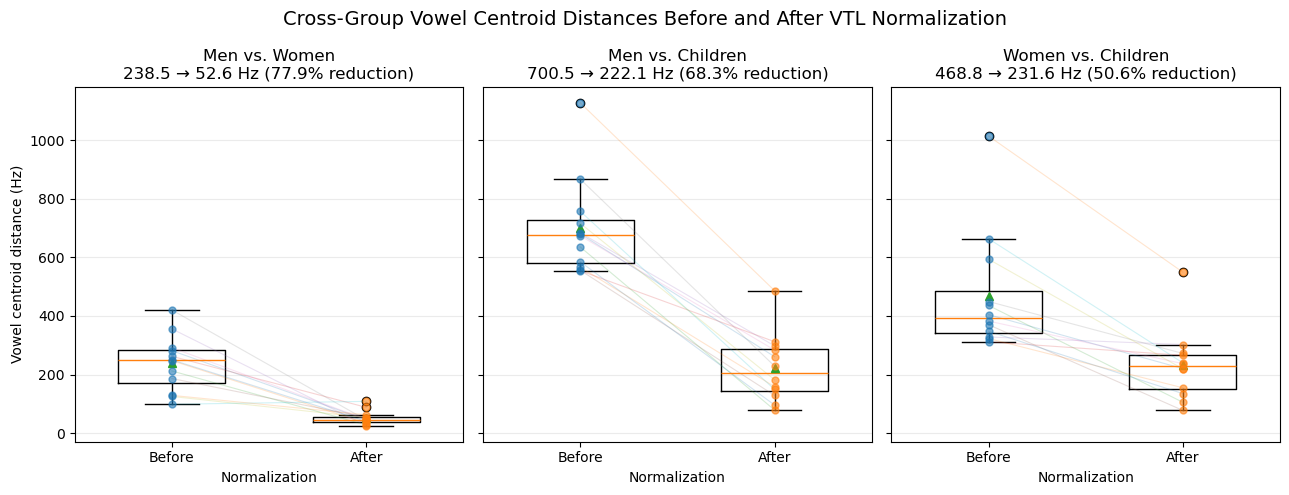

In [20]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 5),
    sharey=True
)

pairs = [
    ("men_women", "men_women_normalized", "Men vs. Women"),
    ("men_children", "men_children_normalized", "Men vs. Children"),
    ("women_children", "women_children_normalized", "Women vs. Children"),
]

for ax, (before_key, after_key, title) in zip(axes, pairs):

    before = pairwise_distances[before_key]["distance"].to_numpy()
    after = pairwise_distances[after_key]["distance"].to_numpy()

    # Before vs. After side-by-side
    ax.boxplot(
        [before, after],
        positions=[1, 2],
        widths=0.55,
        tick_labels=["Before", "After"],
        showmeans=True
    )

    # Show individual vowel distances
    ax.scatter(
        np.full(len(before), 1),
        before,
        alpha=0.6,
        s=25,
        zorder=3
    )

    ax.scatter(
        np.full(len(after), 2),
        after,
        alpha=0.6,
        s=25,
        zorder=3
    )

    for b, a in zip(before, after):
        ax.plot(
            [1, 2],
            [b, a],
            alpha=0.2,
            linewidth=0.8
        )

    # Percentage reduction in mean distance
    mean_before = before.mean()
    mean_after = after.mean()

    reduction = (
        (mean_before - mean_after)
        / mean_before * 100
    )

    ax.set_title(
        f"{title}\n"
        f"{mean_before:.1f} → {mean_after:.1f} Hz "
        f"({reduction:.1f}% reduction)"
    )

    ax.set_xlabel("Normalization")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Vowel centroid distance (Hz)")

fig.suptitle(
    "Cross-Group Vowel Centroid Distances Before and After VTL Normalization",
    fontsize=14
)

plt.tight_layout()
plt.savefig(os.path.join(plot_out_dir, "cross_group_vowel_distances.pdf"))
plt.show()